## Context 

E-Mart is a Chinese retailer that discovered the e-commerce as a way to sell to the entire world, rather than just to the population of their home city. The company has been growing without much worries, and now It wants to start using the data collected during its 4 years of e-commerce to keep growing and make more money.

Cycle 1 

The board of directors expects:

- A Dashboard with KPIs to track their growth.

- Robust Data Analysis, as well as recommendation of actions. What's the actionable based on your analysis?

- **An Analysis about the countries, a segmentation by sales, profit and more. They need insights to help increasing revenue.**

- Sales forecast for the next year, in order to enable strategic planning.

## Agenda


[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Countries Analytical Base Table](#1-Countries-Analytical-Base-Table)<br>
&emsp;[1.1 Group by Transactions](#1.1-Group-by-Transactions)<br>
&emsp;[1.2 Group by Countries](#1.2-Group-by-Countries)<br>
&emsp;[1.3 Merge with Clusters Table](#1.3-Merge-with-Clusters-Table)<br>

[2 Analysis](#2-Analysis)<br>
&emsp;[2.1 Countries](#2.1-Countries)<br>
&emsp;[2.2 Transactions](#2.2-Transactions)<br>

## 0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 0.1 Helper Functions

In [2]:
def boxplot(cluster, y, data, showfliers=False, xticks_rotation=0, figsize=(15, 5)):
    fig(figsize[0], figsize[1])
    plt.subplot( 1, 2, 1 )
    sns.boxplot( x=cluster, y=y[0], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    plt.subplot( 1, 2, 2 )
    sns.boxplot( x=cluster, y=y[1], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    
def count_plot(data, cluster_col="cluster", palette='crest_r', title='countplot'):
    plt.box(False)
    ax = sns.countplot(y=cluster_col, data=data, palette=palette)
    plt.title(title)
    plt.tick_params(axis='both', length=0)
    plt.xlabel(None)
    for p in ax.patches:
        ax.annotate('{:.0f}'.format(p.get_width()), (p.get_width()+5, p.get_y()+.5))
        
        
def cluster_stats(df, column, cluster='cluster', quantile_1=.8, quantile_2=.9):    
    stats = df.groupby(cluster)[[column]].describe()[column]
    quantiles = pd.concat([df.groupby(cluster)[[column]].quantile(quantile_1), df.groupby(cluster)[[column]].quantile(quantile_2)], axis=1)
    quantile_1_name, quantile_2_name = f'{round(quantile_1*100)}%', f'{round(quantile_2*100)}%'
    quantiles.columns = [quantile_1_name, quantile_2_name]
    stats = pd.concat([stats, quantiles], axis=1)
    return stats[['mean', 'std', 'min', '25%', '50%', '75%', quantile_1_name, quantile_2_name, 'max']]

def get_cluster_palette(categories, colors=None):
    """
    Defines colors of category for customer segmentation plots.

    Parameters
    ----------
    categories: category name or list of categories to set a color.
    
    colors: list of colors to be used to color the categories.
    
    Returns
    -------
    segment_color: dict of categories and respective colors.
    """
    
    if colors is None:
        colors = ['#034488', '#027dc5', '#c5253d']
    segment_color = {
        0: 'grey',
        1: 'grey',
        2: 'grey',
        3: 'grey',
        4: 'grey',
        5: 'grey',
    }
    if isinstance(categories, list):
        for i in range(len(categories)):
            segment_color[categories[i]] = colors[i]
    else:
        segment_color[categories] = colors[0]
    return segment_color

### 0.2 Loading Data

In [3]:
directory = Directory("pr_v01_geographic_segmentation", is_sub_project=True)

In [4]:
data = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "e_mart_data.parquet"]))

## 1 Countries Analytical Base Table

### 1.1 Group by Transactions

In [5]:
year = 2014

aggregation = {
    'ship_mode':'unique',
    'order_priority':'unique',
    'segment':'unique',
    'category':'unique',
    'customer_id':'unique',
    'city':'unique',
    'state':'unique',
    'market':'unique',
    'region':'unique',
    'category':'unique',
    'sub_category':'unique',
    'product_id':'unique',
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean',
    'shipping_cost':'sum',
    'cost':'sum',
#     'sales_without_discount':'sum',
#     'profit_per_product':'sum',
#     'product_value':'sum',
#     'product_cost':'sum',
#     'order_date_year':'mean',
#     'order_date_month':'mean',
#     'order_date_day':'mean',
    'is_profitable_sale':'mean',    
    'order_date':'max',
}
transactions = data[data['order_date_year'] == year].groupby(["country", "order_id"]).agg(aggregation).reset_index()
transactions.head(2)

,country,order_id,ship_mode,order_priority,segment,category,customer_id,city,state,market,...,sub_category,product_id,sales,quantity,profit,discount,shipping_cost,cost,is_profitable_sale,order_date
0,Afghanistan,IN-2014-18791-TS-21205,[Standard Class],[Medium],[Corporate],[Office Supplies],[TS-21205],[Kabul],[Kabul],[APAC],...,"[Envelopes, Labels]","[OFF-EN-10003715, OFF-LA-10000108]",143.97,8,31.95,0.0,9.45,102.57,1.0,2014-06-18
1,Afghanistan,IN-2014-20415-GM-14455,[Standard Class],[Medium],[Home Office],"[Furniture, Office Supplies]",[GM-14455],[Kabul],[Kabul],[APAC],...,"[Bookcases, Fasteners]","[FUR-BO-10002204, OFF-FA-10004027]",2115.51,9,850.86,0.0,187.81,1076.84,1.0,2014-01-08


In [6]:
get_value = lambda x: x[0] if len(x)<=1 else 'Mix'
columns = ['ship_mode','order_priority','segment','category','city',
           'state','market','region', 'sub_category','customer_id', 'product_id']
for col in columns:
    transactions[col] = transactions[col].apply(get_value)
transactions.head(2)

,country,order_id,ship_mode,order_priority,segment,category,customer_id,city,state,market,...,sub_category,product_id,sales,quantity,profit,discount,shipping_cost,cost,is_profitable_sale,order_date
0,Afghanistan,IN-2014-18791-TS-21205,Standard Class,Medium,Corporate,Office Supplies,TS-21205,Kabul,Kabul,APAC,...,Mix,Mix,143.97,8,31.95,0.0,9.45,102.57,1.0,2014-06-18
1,Afghanistan,IN-2014-20415-GM-14455,Standard Class,Medium,Home Office,Mix,GM-14455,Kabul,Kabul,APAC,...,Mix,Mix,2115.51,9,850.86,0.0,187.81,1076.84,1.0,2014-01-08


In [7]:
transactions['avg_order_profit'] = transactions['profit']
transactions['avg_order_cost'] = transactions['cost']
transactions['avg_order_products'] = transactions['quantity']
transactions['avg_order_sales'] = transactions['sales']
transactions['avg_order_shipping_cost'] = transactions['shipping_cost']
transactions['avg_order_discount'] = transactions['discount']

### 1.2 Group by Countries

In [8]:
aggregation = {
    'ship_mode':'unique',
    'order_priority':'unique',
    'segment':'unique',
    'category':'unique',
    'order_id':'nunique',
    'customer_id':'nunique',
    'product_id':'nunique',
    'city':'nunique',
    'state':'nunique',
    'region':'nunique',
    'market':'unique',    
    'category':'nunique',
    'sub_category':'nunique',
    'sales':'sum',
    'quantity':'sum',
    'avg_order_profit':'mean',
    'avg_order_cost':'mean',
    'avg_order_products':'mean',
    'avg_order_sales':'mean',
    'avg_order_shipping_cost':'mean',
    'avg_order_discount':'mean',
    'profit':'sum',
    'discount':'sum',
    'shipping_cost':'sum',
    'cost':'sum',
#     'sales_without_discount':'sum',
    'shipping_cost':'sum',
#     'profit_per_product':'sum',
#     'product_value':'sum',
#     'product_cost':'sum',
    'is_profitable_sale':'mean',    
#     'order_date':'max',
}
countries_abt = transactions.groupby('country').agg(aggregation)
countries_abt.head(2)

,ship_mode,order_priority,segment,category,order_id,customer_id,product_id,city,state,region,...,avg_order_cost,avg_order_products,avg_order_sales,avg_order_shipping_cost,avg_order_discount,profit,discount,shipping_cost,cost,is_profitable_sale
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,"[Standard Class, First Class, Second Class]","[Medium, High]","[Corporate, Home Office, Consumer]",3,9,9,5,3,3,1,...,432.763333,8.444444,736.586667,71.236667,0.0,2093.28,0.0,641.13,3894.87,1.0
Albania,[Second Class],[High],[Consumer],1,1,1,1,1,1,1,...,275.480000,11.000000,411.210000,48.220000,0.0,87.51,0.0,48.22,275.48,1.0


In [9]:
ship_mode = pd.get_dummies(countries_abt['ship_mode'].explode(), prefix='ship_mode').reset_index().groupby('country').sum()
order_priority = pd.get_dummies(countries_abt['order_priority'].explode(), prefix='order_priority').reset_index().groupby('country').sum()
segment = pd.get_dummies(countries_abt['segment'].explode(), prefix='segment').reset_index().groupby('country').sum()
market = pd.get_dummies(countries_abt['market'].explode(), prefix='market').reset_index().groupby('country').sum()

In [10]:
countries_abt = countries_abt.join(ship_mode)
countries_abt = countries_abt.join(order_priority)
countries_abt = countries_abt.join(segment)
countries_abt = countries_abt.join(market)

countries_abt.drop(columns=['ship_mode','order_priority','segment','market'], inplace=True)
countries_abt.head(2)

,category,order_id,customer_id,product_id,city,state,region,sub_category,sales,quantity,...,segment_Consumer,segment_Corporate,segment_Home Office,market_APAC,market_Africa,market_Canada,market_EMEA,market_EU,market_LATAM,market_US
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,3,9,9,5,3,3,1,4,6629.28,76,...,1,1,1,1,0,0,0,0,0,0
Albania,1,1,1,1,1,1,1,1,411.21,11,...,1,0,0,0,0,0,1,0,0,0


### 1.3 Merge with Clusters Table

In [11]:
clusters = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "country_segmentation", "countries_and_clusters.parquet"]))
clusters.head(2)

,country,cluster
0,Afghanistan,Good Performance
1,Albania,Good Performance


In [12]:
countries_abt = countries_abt.reset_index().merge(clusters, how='outer')
countries_abt.head(2)

,country,category,order_id,customer_id,product_id,city,state,region,sub_category,sales,...,segment_Corporate,segment_Home Office,market_APAC,market_Africa,market_Canada,market_EMEA,market_EU,market_LATAM,market_US,cluster
0,Afghanistan,3,9,9,5,3,3,1,4,6629.28,...,1,1,1,0,0,0,0,0,0,Good Performance
1,Albania,1,1,1,1,1,1,1,1,411.21,...,0,0,0,0,0,1,0,0,0,Good Performance


In [13]:
transactions = transactions.merge(clusters, how='outer')

In [14]:
# countries_abt.isna().sum()

## 2 Analysis

**Countries with:**

**_Good Performance_** - Each Country has

    
        Profit:
            Average Profit = $ 2,890
        Average transaction Profit: $ 122
            
        Sales:
            Average Sales = $ 13,201
        Average transaction Sale Value: $ 500
            
        Discounts:
            Lowest Discounts (90% of them are below 1%)
            
        Shipping Cost:
            Total Shipping Cost of about $ 1,433
        Average transaction Shipping Cost: $ 55
            

**_Bad Performance_** - Each Country has


        Profit:
            Average Profit: (Deficit) 90% of profit is lower than $ -176 
                      Total profit of about $ -4591
            Average transaction Profit: $ -129
            
        Sales:
            Average Sales = $ 19,539
        Average transaction Sale Value: $ 303
            
        Discounts:
            Very High Discounts (varying from 20% to 70%)
            
        Shipping Cost:
            Total Shipping Cost of about $ 2,070
        Average transaction Shipping Cost: $ 31
            

**_High Performance_** - Each Country has


        Profit:
            Average Profit: over $ 30,000
        Average transaction Profit: $ 103
            
        Sales:
            Average Sales over $ 190,000
        Average transaction Sale Value: $ 611
            
        Discounts:
            Below 16%
            
        Shipping Cost:
            Total Shipping Cost Over $ 19,000
        Average transaction Shipping Cost: $ 65

### 2.1 Countries

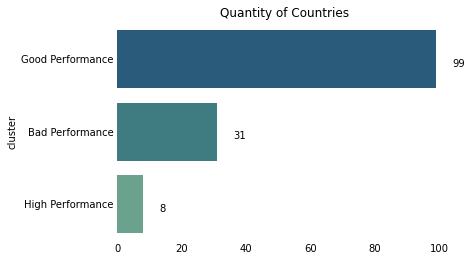

In [15]:
count_plot(countries_abt, cluster_col="cluster", palette='crest_r', title='Quantity of Countries');

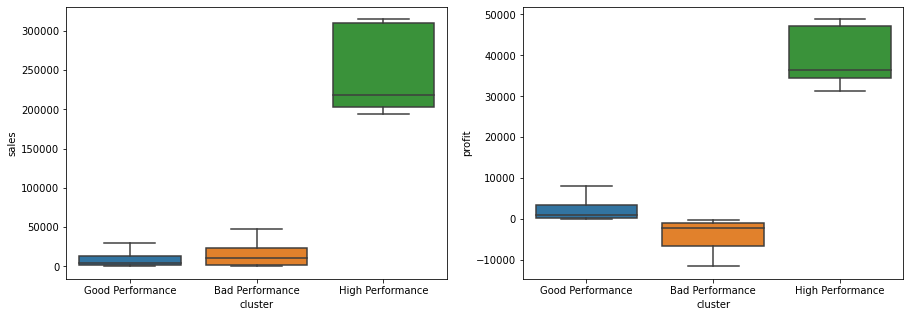

In [16]:
boxplot( cluster='cluster', y=['sales', 'profit'], data=countries_abt, showfliers=0)

In [17]:
cluster_stats(countries_abt, 'sales', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,19539.280219,28971.063648,150.480,1804.77000,10332.8670,23992.959060,29442.243240,39316.15704,145334.78100
Good Performance,13201.997036,21520.624403,49.500,1687.70100,4775.8500,13263.865500,28179.670048,35233.21800,119772.11332
High Performance,298393.809652,182555.824952,194005.041,202643.91263,217758.1605,310011.257625,314418.312375,440497.27836,733947.02320


In [18]:
countries_abt.groupby('cluster')[['order_id']].sum()

,order_id
cluster,
Bad Performance,1724
Good Performance,2786
High Performance,4357


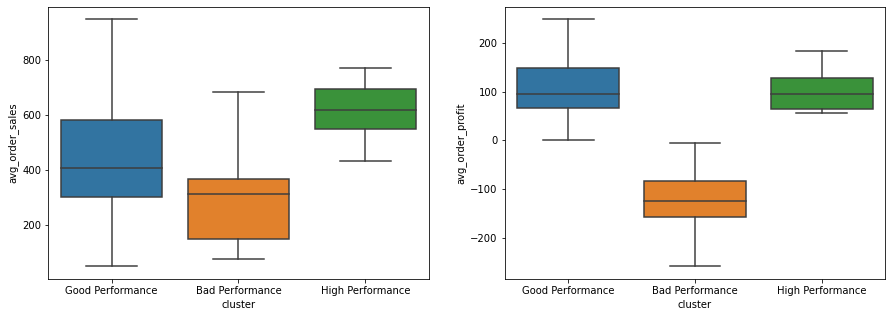

In [19]:
boxplot( cluster='cluster', y=['avg_order_sales', 'avg_order_profit'], data=countries_abt, showfliers=0)

In [20]:
cluster_stats(countries_abt, 'avg_order_sales', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,303.742057,177.528021,76.098375,150.025500,312.199461,366.092071,560.182940,566.084232,684.926754
Good Performance,500.076008,357.158028,49.500000,303.048333,407.411545,581.619375,742.782178,890.891784,2055.361000
High Performance,611.844699,119.083853,433.774836,549.003975,618.308059,695.809307,725.392850,740.493253,770.796936


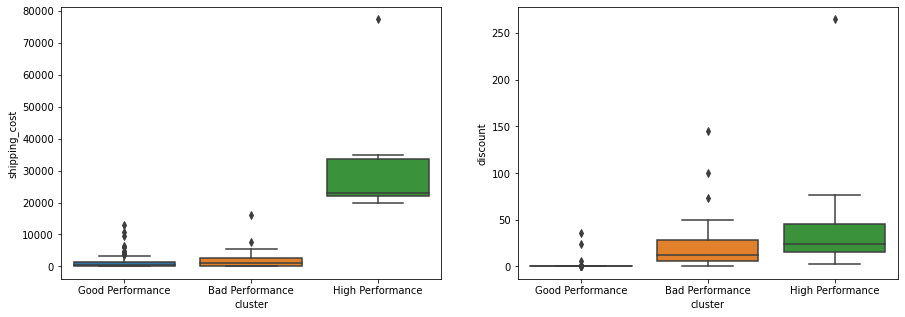

In [21]:
boxplot( cluster='cluster', y=['shipping_cost', 'discount'], data=countries_abt, showfliers=1)

In [22]:
cluster_stats(countries_abt, 'shipping_cost', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,2070.152903,3143.771250,11.75,197.605,1003.650,2535.3850,3296.1250,3988.470,16056.22
Good Performance,1433.364747,2284.208830,2.68,154.710,521.770,1488.9900,3147.9050,3597.712,12961.19
High Performance,31803.740000,19200.382806,19954.71,21939.395,23116.805,33454.0225,34676.3975,47518.816,77280.73


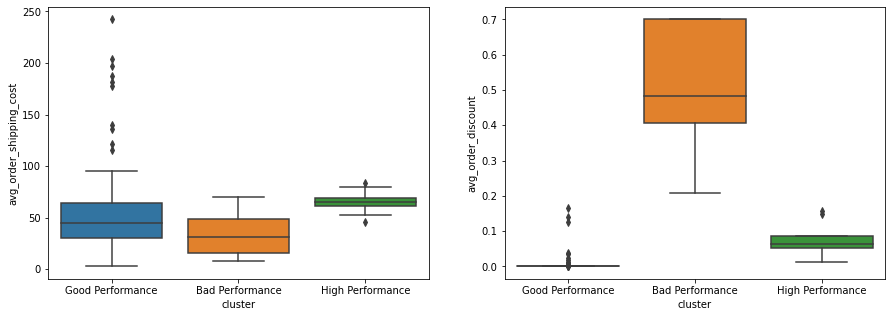

In [23]:
boxplot( cluster='cluster', y=['avg_order_shipping_cost', 'avg_order_discount'], data=countries_abt, showfliers=1)

In [24]:
cluster_stats(countries_abt, 'avg_order_discount', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,0.491426,0.162158,0.207477,0.406989,0.484135,0.700000,0.700000,0.700000,0.700000
Good Performance,0.005819,0.025430,0.000000,0.000000,0.000000,0.000000,0.000127,0.003214,0.166667
High Performance,0.073977,0.052971,0.011278,0.051751,0.063728,0.086448,0.144632,0.151047,0.156317


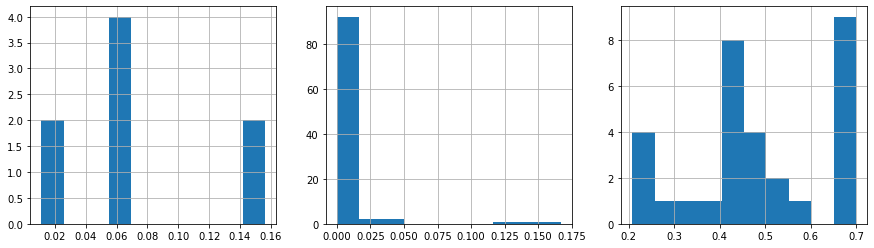

In [25]:
# Average Discount of Countries
fig(15, 4)
plt.subplot(1,3,1)
countries_abt[countries_abt['cluster'] == 'High Performance']['avg_order_discount'].hist()
plt.subplot(1,3,2)
countries_abt[countries_abt['cluster'] == 'Good Performance']['avg_order_discount'].hist()
plt.subplot(1,3,3)
countries_abt[countries_abt['cluster'] == 'Bad Performance']['avg_order_discount'].hist();

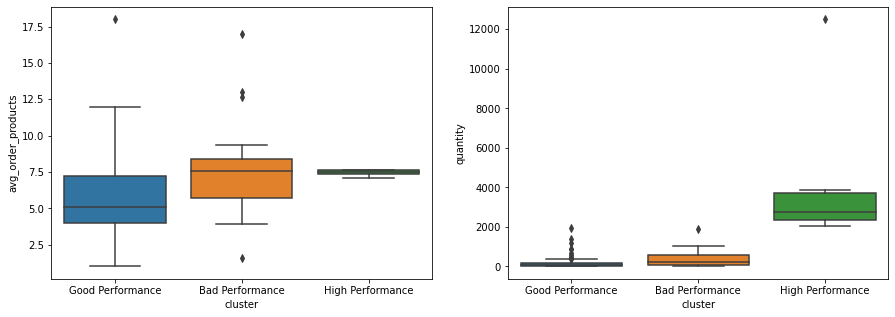

In [26]:
boxplot( cluster='cluster', y=['avg_order_products', 'quantity'], data=countries_abt, showfliers=1)

In [27]:
cluster_stats(countries_abt, 'quantity', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,378.322581,418.869700,8.0,73.0,238.0,588.50,721.50,877.0,1900.0
Good Performance,167.949495,303.123346,1.0,17.5,54.0,168.00,332.40,400.0,1932.0
High Performance,4033.375000,3487.650783,2035.0,2342.5,2776.0,3710.25,3856.55,6457.8,12503.0


### 2.2 Transactions

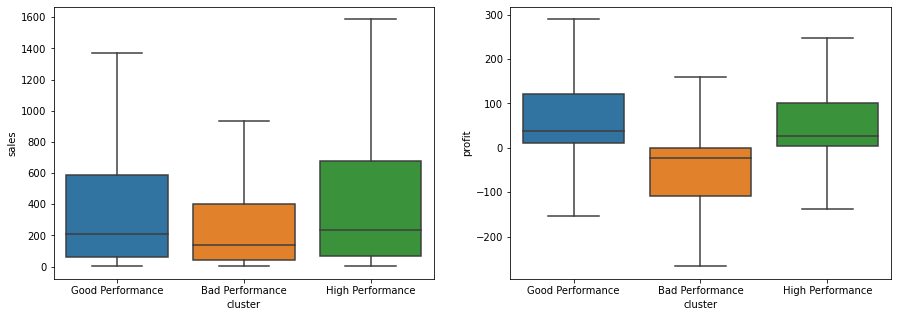

In [28]:
boxplot( cluster='cluster', y=['sales', 'profit'], data=transactions, showfliers=0)

In [29]:
cluster_stats(transactions, 'discount', quantile_1=.85, quantile_2=.95)

,mean,std,min,25%,50%,75%,85%,95%,max
cluster,,,,,,,,,
Bad Performance,0.429240,0.176843,0.0,0.32,0.400000,0.60,0.6,0.700000,0.700
Good Performance,0.025234,0.103440,0.0,0.00,0.000000,0.00,0.0,0.138333,0.601
High Performance,0.103696,0.156636,0.0,0.00,0.033333,0.15,0.2,0.450000,0.800


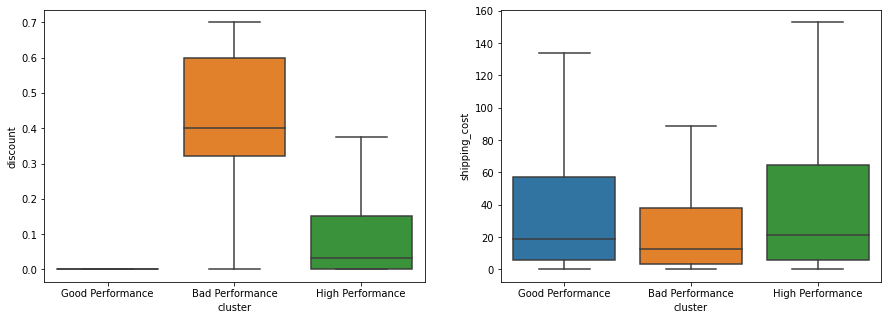

In [30]:
boxplot( cluster='cluster', y=['discount', 'shipping_cost'], data=transactions, showfliers=0)

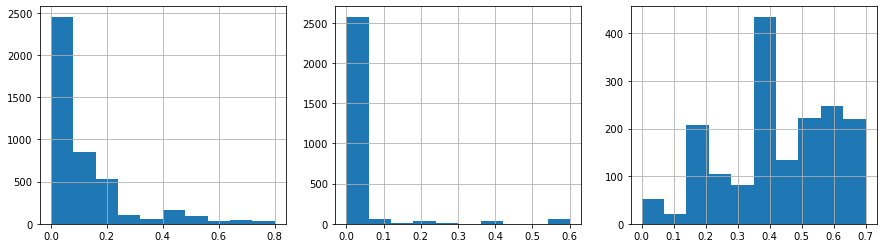

In [31]:
# Average Discount of Transactions
fig(15, 4)
plt.subplot(1,3,1)
transactions[transactions['cluster'] == 'High Performance']['discount'].hist()
plt.subplot(1,3,2)
transactions[transactions['cluster'] == 'Good Performance']['discount'].hist()
plt.subplot(1,3,3)
transactions[transactions['cluster'] == 'Bad Performance']['discount'].hist();

Just as in countries_abt

In [32]:
# aux = transactions.groupby('country').agg({'cluster':'unique', 'discount':'mean'})#.apply(lambda x: len(x)).max()
# aux['cluster'] = aux['cluster'].apply(lambda x: x[0])
# aux.head(2)

In [33]:
# fig(15, 4)
# plt.subplot(1,3,1)
# aux[aux['cluster'] == 'High Performance']['discount'].hist()
# plt.subplot(1,3,2)
# aux[aux['cluster'] == 'Good Performance']['discount'].hist()
# plt.subplot(1,3,3)
# aux[aux['cluster'] == 'Bad Performance']['discount'].hist();

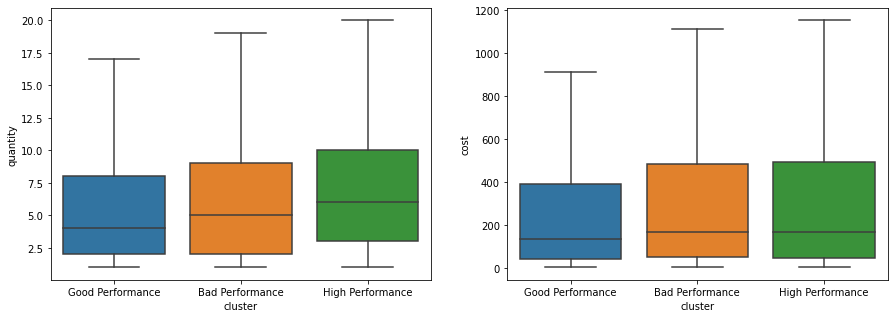

In [34]:
boxplot( cluster='cluster', y=['quantity', 'cost'], data=transactions, showfliers=0)

In [35]:
cluster_stats(transactions, 'quantity', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
Bad Performance,6.802784,6.060583,1.0,2.0,5.0,9.0,12.0,15.0,45.0
Good Performance,5.968055,5.458647,1.0,2.0,4.0,8.0,11.0,13.0,45.0
High Performance,7.405784,6.050760,1.0,3.0,6.0,10.0,13.0,15.0,58.0


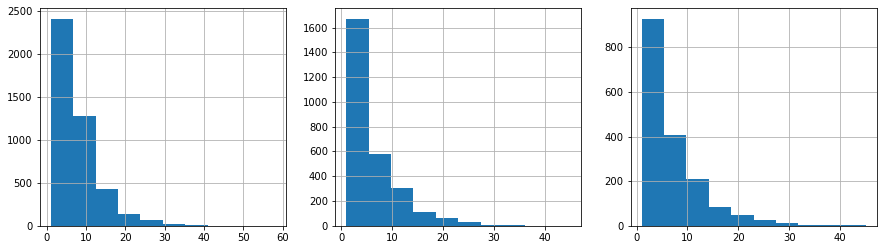

In [36]:
# Average Discount of Transactions
fig(15, 4)
plt.subplot(1,3,1)
transactions[transactions['cluster'] == 'High Performance']['quantity'].hist()
plt.subplot(1,3,2)
transactions[transactions['cluster'] == 'Good Performance']['quantity'].hist()
plt.subplot(1,3,3)
transactions[transactions['cluster'] == 'Bad Performance']['quantity'].hist();

In [37]:
# transactions.groupby(['cluster']).country.nunique()

In [38]:
# transactions.groupby(['cluster', 'country'])['profit'].agg(['mean','sum']).reset_index().groupby('cluster').agg(['mean','sum'])

In [42]:
clusters.to_csv(join_paths([directory.DATA_DIR, "processed", "country_segmentation", "countries_and_clusters.csv"]), index=0)
transactions.to_csv(join_paths([directory.DATA_DIR, "processed", "country_segmentation", "transactions.csv"]), index=0)

In [78]:
deficit = transactions[transactions['cluster'] == 'Bad Performance']
profit = transactions[transactions['cluster'] == 'Bad Performance']
pro_plus = transactions[transactions['cluster'] == 'Bad Performance']

In [96]:
def separate_discount(df, discount=.35):
    lower_discounts = df[df['discount'] < discount]
    higher_discounts = df[df['discount'] >= discount]
    return lower_discounts, higher_discounts

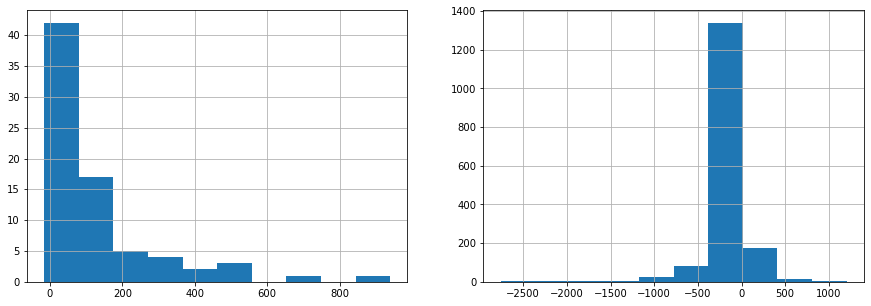

In [100]:
lower_discounts, higher_discounts = separate_discount(deficit, discount=.15)
fig()
plt.subplot(1,2,1)
lower_discounts['profit'].hist()
plt.subplot(1,2,2)
higher_discounts['profit'].hist();